# Image Classification Model

## Dataset

In [8]:
import tensorflow as tf

DATA_DIR = '/content/drive/MyDrive/renders'

BATCH_SIZE = 32
IMG_SIZE = (256, 256)

# Keras ile klasörden verileri okuma
full_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

class_names = full_dataset.class_names
print(f"Classes: {class_names}")

# Veriyi %70, %15, %15 oranında bölme
total_batches = tf.data.experimental.cardinality(full_dataset).numpy()

train_batches = int(total_batches * 0.7)
val_batches = int(total_batches * 0.15)
test_batches = total_batches - train_batches - val_batches

train_dataset = full_dataset.take(train_batches)
val_dataset = full_dataset.skip(train_batches).take(val_batches)
test_dataset = full_dataset.skip(train_batches + val_batches)

# GPU resim işlerken CPU bir sonrakini RAM'de hazır bekletir (cache)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(f"Train: {train_batches}, Validation: {val_batches}, Test: {test_batches}")

Found 1984 files belonging to 2 classes.
Classes: ['humanoid', 'quadruped']
Train: 43, Validation: 9, Test: 10


## EfficientNetB0 Model (Transfer Learning)

In [9]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    layers.RandomZoom(0.1),
])

# include_top=False: Modelin sonundaki "1000 farklı nesneyi tanıyan" karar katmanını kesip atıyoruz.
base_model = EfficientNetB0(weights='imagenet', input_shape=(256, 256, 3), include_top=False)

# Beyni "Donduruyoruz". Bizim küçük verimizle, daha önce öğrendiği temel bilgileri unutmasını istemiyoruz.
base_model.trainable = False

# Kendi Karar Mekanizmamızı (Top Layers) Ekliyoruz
inputs = layers.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)

# Modeli bağlıyoruz (EfficientNet önişlemeyi kendi yapar)
x = base_model(x, training=False)

# Çıkan 3 boyutlu karmaşık özellikleri, tek boyutlu düz bir listeye çeviriyoruz
x = layers.GlobalAveragePooling2D()(x)

# Nöronların %20'sini rastgele kapat (Ezberlemeyi - Overfitting - önler)
x = layers.Dropout(0.2)(x)

# Bizim 2 sınıfımız (Humanoid, Quadruped) için son karar katmanı
outputs = layers.Dense(len(class_names), activation='softmax')(x)

# Modeli Paketle
model = models.Model(inputs, outputs)

# Modeli Derle
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model built succesfully!")

Model built succesfully!


In [10]:
# Model Özeti
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Train Model

In [11]:
from tensorflow.keras import callbacks

MODEL_SAVE_PATH = '/content/drive/MyDrive/auto_rigger_efficientnet.keras'

# Gözlemciler
checkpoint = callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 25

print("Train Starting...")

# Eğitimi Başlat
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)

print(f"\n✅ Train Finished! Saved: {MODEL_SAVE_PATH}")

Train Starting...
Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7710 - loss: 0.4816
Epoch 1: val_accuracy improved from None to 0.95486, saving model to /content/drive/MyDrive/auto_rigger_efficientnet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/auto_rigger_efficientnet.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 337ms/step - accuracy: 0.8685 - loss: 0.3344 - val_accuracy: 0.9549 - val_loss: 0.1632
Epoch 2/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9568 - loss: 0.1584
Epoch 2: val_accuracy improved from 0.95486 to 0.97222, saving model to /content/drive/MyDrive/auto_rigger_efficientnet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/auto_rigger_efficientnet.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.9600 - loss: 0.1426 - val_accuracy: 0.9722 - val_loss: 0.1017
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9764 - loss: 0.1031
Epoch 3: val_accuracy improved from 0.97222 to 0.97917, saving mo

## Metrics

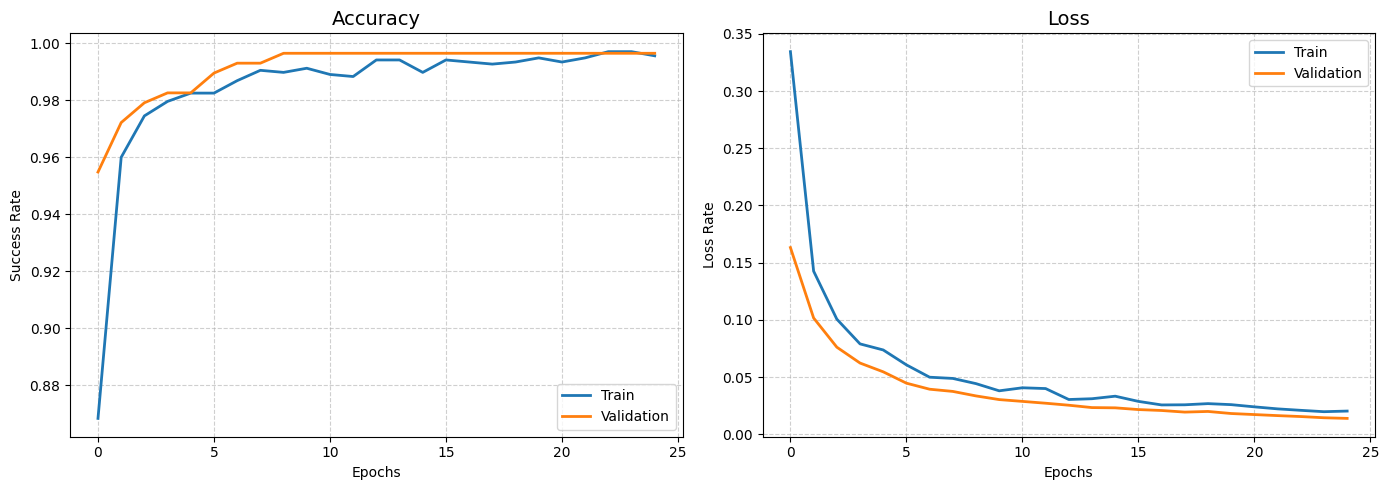

In [14]:
import matplotlib.pyplot as plt

# Eğitim Sürecinin Grafiklerini Çizdir
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Grafikleri yan yana iki panelde göster
plt.figure(figsize=(14, 5))

# Başarı (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train', linewidth=2)
plt.plot(val_acc, label='Validation', linewidth=2)
plt.title('Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Success Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Hata (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train', linewidth=2)
plt.plot(val_loss, label='Validation', linewidth=2)
plt.title('Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss Rate')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [15]:
# evaluate() fonksiyonu modeli test_dataset üzerinde sınar
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)

print(f"Test Success: % {test_acc * 100:.2f}")
print(f"Loss:  {test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9906 - loss: 0.0266
Test Success: % 99.06
Loss:  0.0266
